# Librairies 📚

In [60]:
# =========================
# Standard library
# =========================
import os
import sys
import time
import math
import re
import importlib

# =========================
# Data / scientific stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Stats
# =========================
import scipy.stats as stats
from scipy.stats import kruskal
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import (
    LabelEncoder,
    MultiLabelBinarizer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)

# =========================
# Local imports (src/)
# =========================
sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks

import src.outliers as of

# Import de la table 🪑

In [2]:
info_backup = pd.read_csv("/home/maxime/projects/technova-attrition/data/raw/extrait_sirh.csv.csv")
info_backup.head(2)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7


In [3]:
info = info_backup.copy()
info.shape

(1470, 12)

In [4]:
eval_backup = pd.read_csv("/home/maxime/projects/technova-attrition/data/raw/extrait_eval.csv")
eval_backup.head(2)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %


In [5]:
df_eval = eval_backup.copy()
df_eval.shape

(1470, 10)

In [6]:
poll_backup = pd.read_csv("/home/maxime/projects/technova-attrition/data/raw/extrait_sondage.csv")
poll_backup.head(2)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7


In [7]:
poll = poll_backup.copy()
poll.shape

(1470, 12)

# A.1 Table info (SIRH) ℹ️

## Premier nettoyage des données 🧹

In [8]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


In [9]:
info.drop("id_employee",axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
nombre_heures_travailless,1470.0,80.000000,0.000000,80.0,80.0,80.0,80.0,80.0
annee_experience_totale,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.0,3.0,7.0,18.0


### Valeurs nulles 👌(❎ pas de valeur nulle)

In [10]:
info.isna().mean().sort_values(ascending=False)

id_employee                       0.0
age                               0.0
genre                             0.0
revenu_mensuel                    0.0
statut_marital                    0.0
departement                       0.0
poste                             0.0
nombre_experiences_precedentes    0.0
nombre_heures_travailless         0.0
annee_experience_totale           0.0
annees_dans_l_entreprise          0.0
annees_dans_le_poste_actuel       0.0
dtype: float64

### Suppression des doublons 👥 (❎ Pas de doublons)

In [11]:
info.duplicated().sum()

0

## Analyses univariées 

### Outliers 😶

In [59]:
data = info.drop("id_employee",axis=1).select_dtypes(include="number")

In [13]:
outliers, ratio = of.detect_outliers_iqr(data)
ratio.sort_values(ascending=False)

revenu_mensuel                    7.755102
annees_dans_l_entreprise          7.074830
annee_experience_totale           4.285714
nombre_experiences_precedentes    3.537415
annees_dans_le_poste_actuel       1.428571
age                               0.000000
nombre_heures_travailless         0.000000
dtype: float64

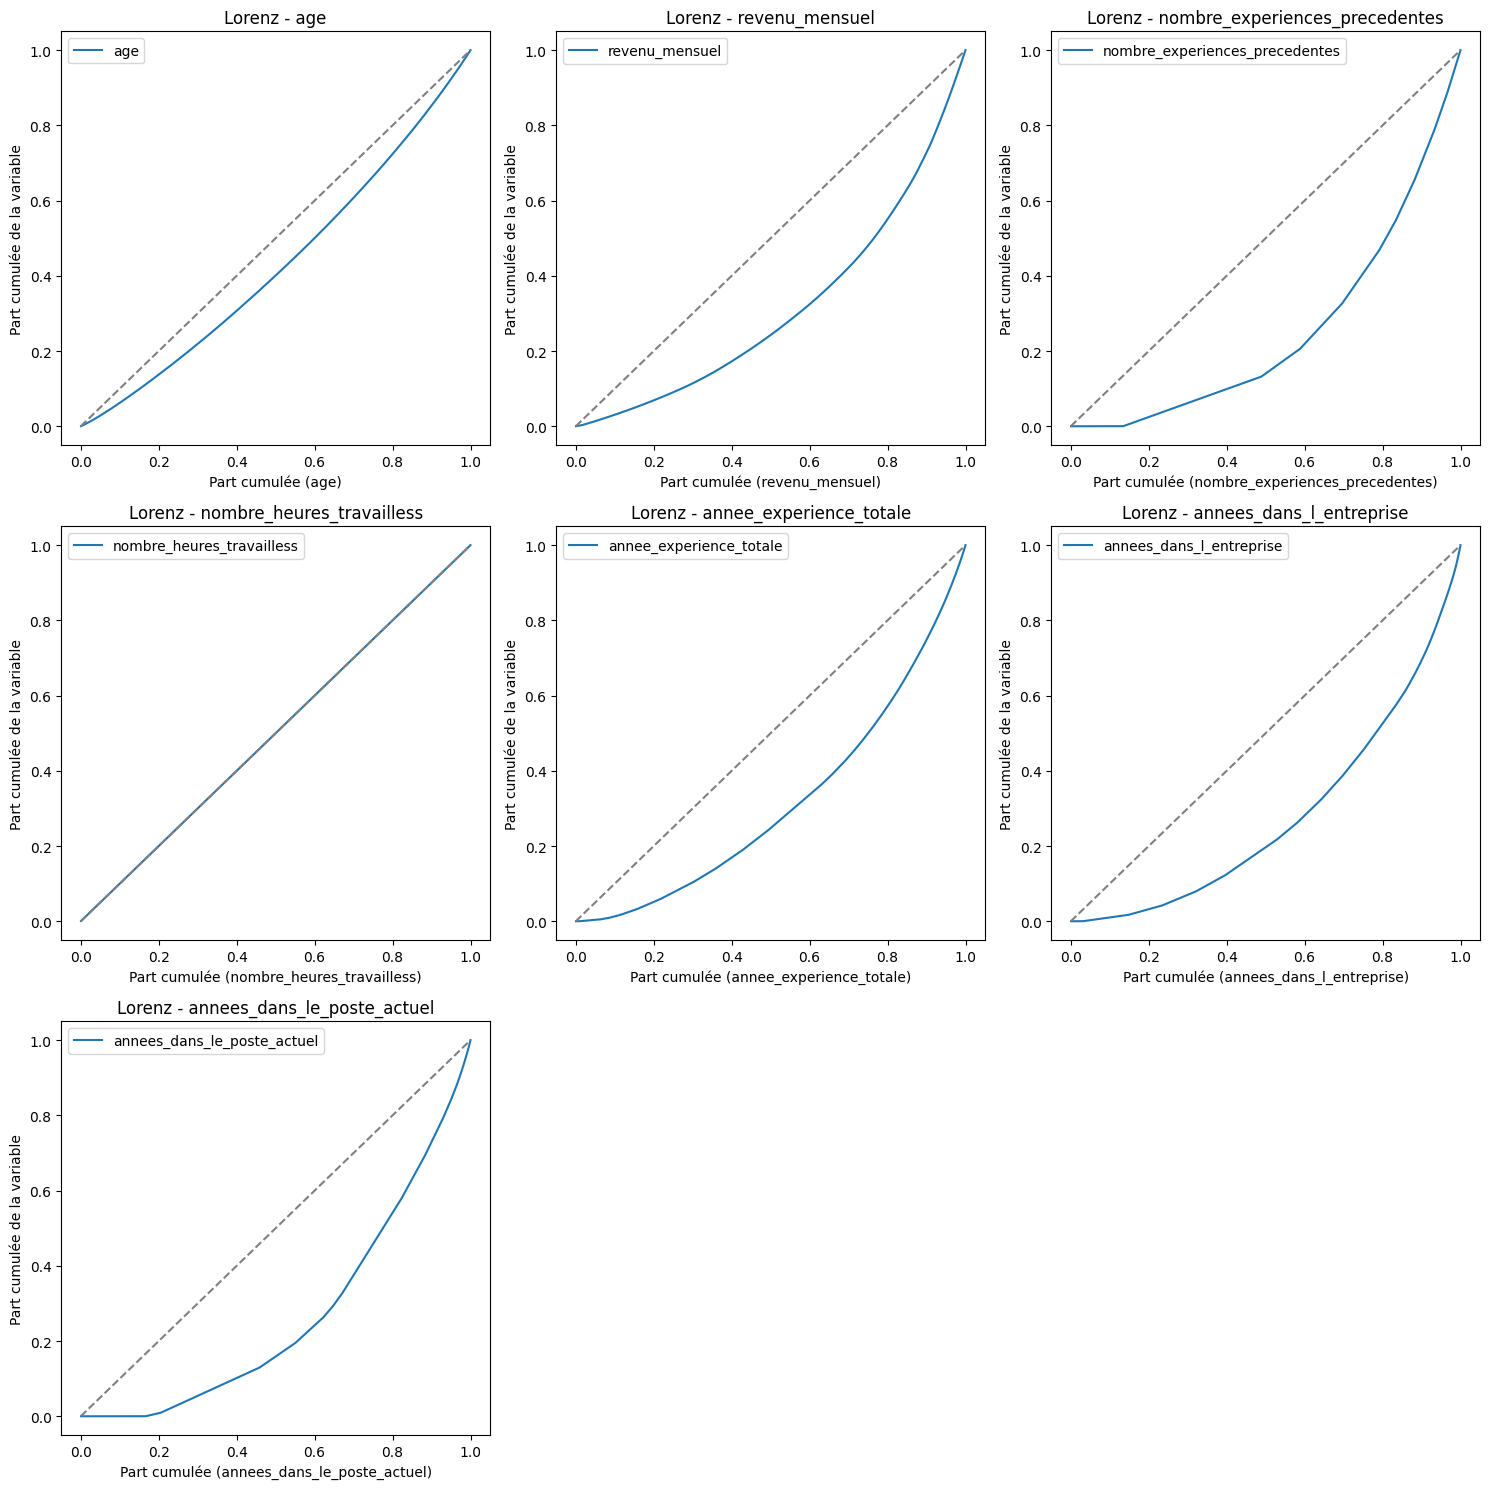

In [14]:
n_cols = 3
n_plots = len(data.columns)

n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, (col, serie) in enumerate(data.items()):
    of.plot_lorenz(
        serie,
        ax=axes[i],
        label=col,
        title=f"Lorenz - {col}"
    )

# Supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

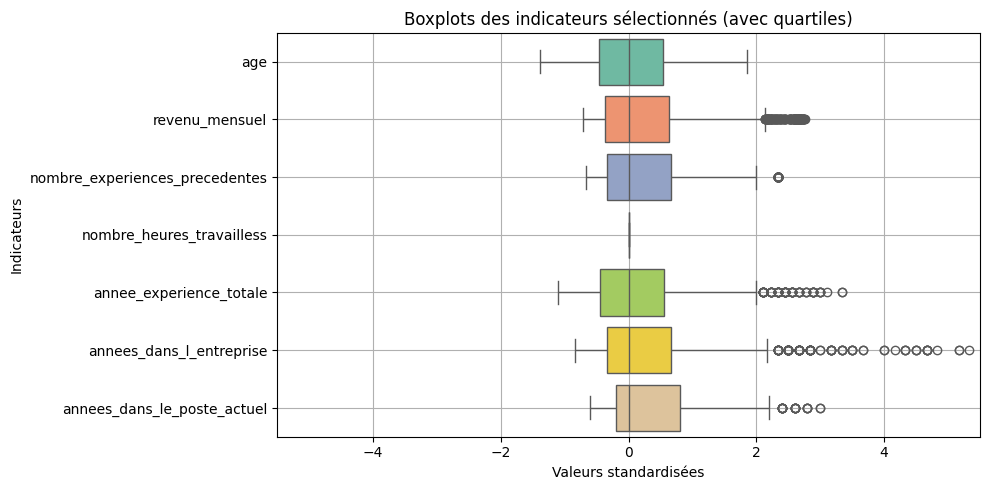

In [ ]:
data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data),
    columns=data.columns
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("")
plt.xlabel("Valeurs normalisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()

3 types de variables :

    Type 1 : Homogènes ==> age, nombre_heures_travaillées : 0% d'outliers

    Type 2 : Moyennement inégal ==> annee_experience_totale, annees_dans_l_entreprise : 3-7% d'outliers

    Type 3 : Très concentré (IMPORTANT) ==> revenu_mensuel, nombre_experiences_precedentes, annees_dans_le_poste_actuel : 7.7% outliers

    ==> 3 variable à log pour le model 

### Skwed

In [15]:
#data = info[["revenu_mensuel", "nombre_experiences_precedentes", "annees_dans_le_poste_actuel"]]
data.skew().sort_values(ascending=False)

annees_dans_l_entreprise          1.764529
revenu_mensuel                    1.369817
annee_experience_totale           1.117172
nombre_experiences_precedentes    1.026471
annees_dans_le_poste_actuel       0.917363
age                               0.413286
nombre_heures_travailless         0.000000
dtype: float64

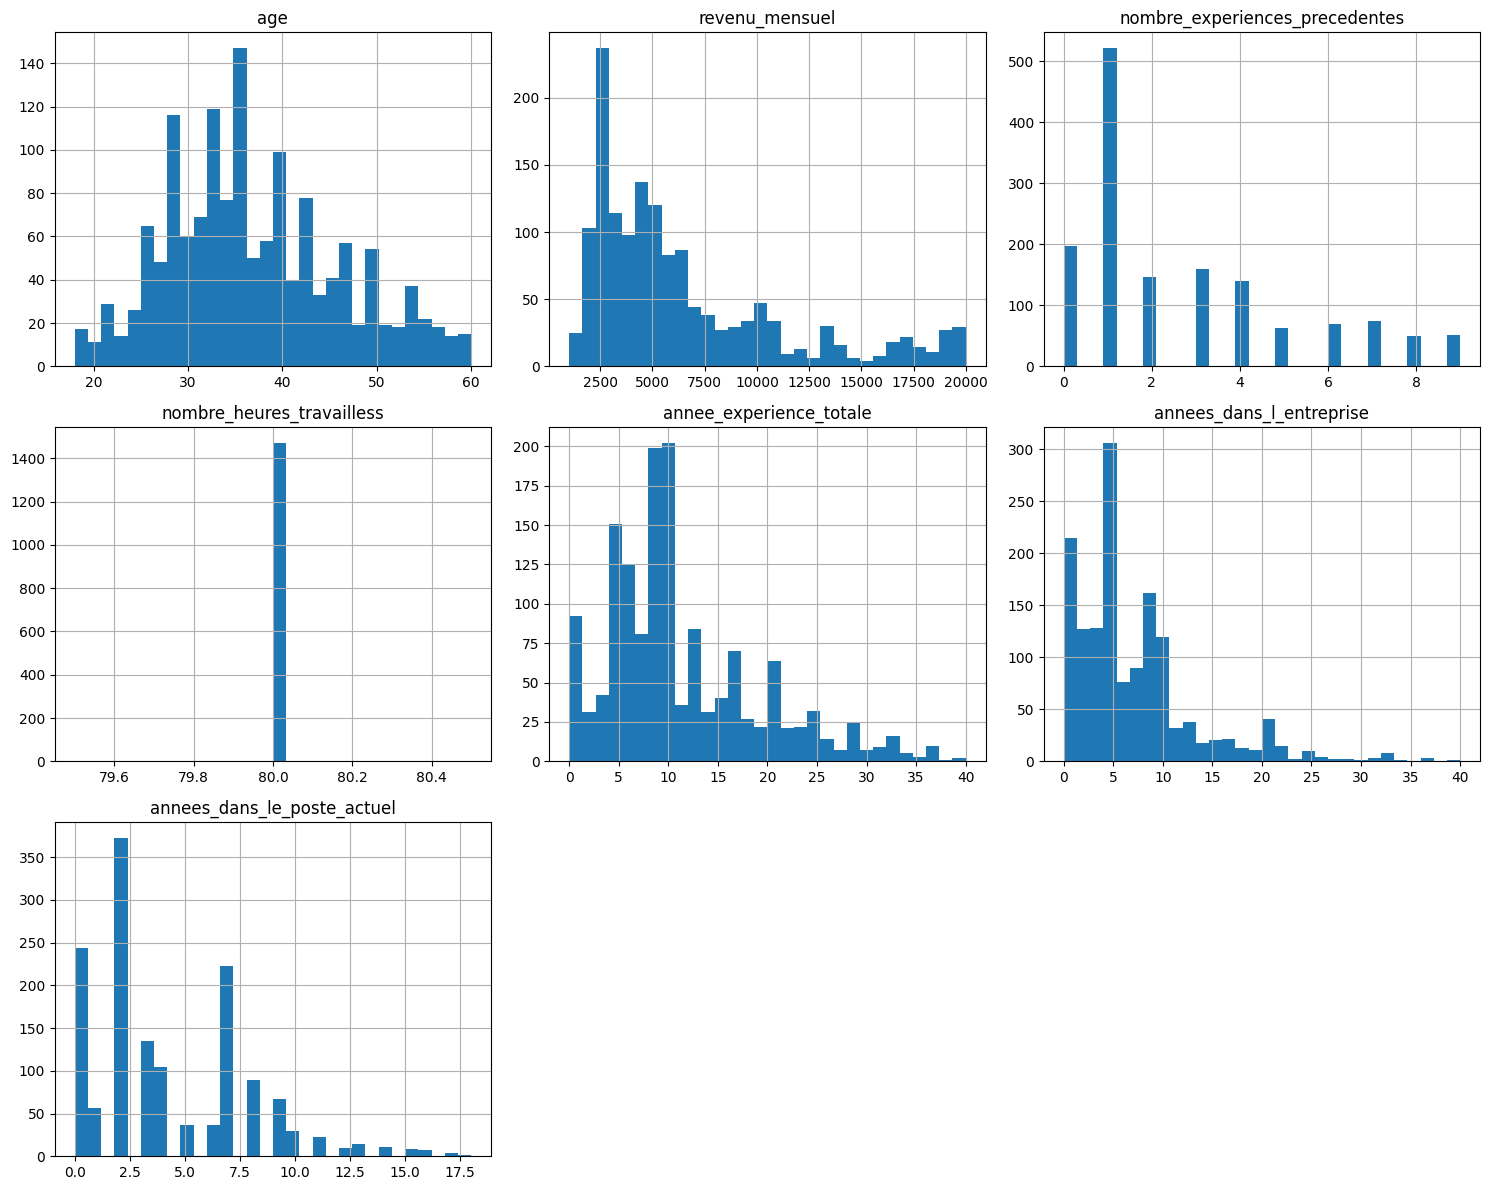

In [16]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

## 🧠 Analyse univariée - info — Synthèse & Actions

### 1. ⚠️ Analyse des outliers (IQR)

* Jusqu’à ~8% d’outliers sur certaines variables (notamment `revenu_mensuel`)
* Ces outliers sont **structurels** (non aberrants métier)

➡️ **Aucune suppression d’outliers recommandée**

---

### 2. 📊 Swed

#### 🟠 Variables modérément asymétriques

* `annee_experience_totale`
* `annees_dans_l_entreprise`

➡️ Distribution réaliste avec une dispersion modérée.

---

#### 🔴 Variables fortement asymétriques (skew à droite)

* `revenu_mensuel`
* `annees_dans_le_poste_actuel`
* `nombre_experiences_precedentes`

➡️ Présence de valeurs extrêmes et forte concentration (confirmée par la courbe de Lorenz).

---

### ✅ Variables potentiellement à transformer (selon modèle)

```python
[
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel"
]
```
### 📌 Conclusion

L’analyse univariée met en évidence des distributions hétérogènes avec :

* des variables homogènes (âge),
* des variables modérément dispersées (expérience),
* et des variables fortement asymétriques (revenu).

Ces résultats orientent les choix de preprocessing et confirment l’intérêt d’utiliser des modèles robustes aux distributions non gaussiennes.

---


## Analyses bivariées 🪢

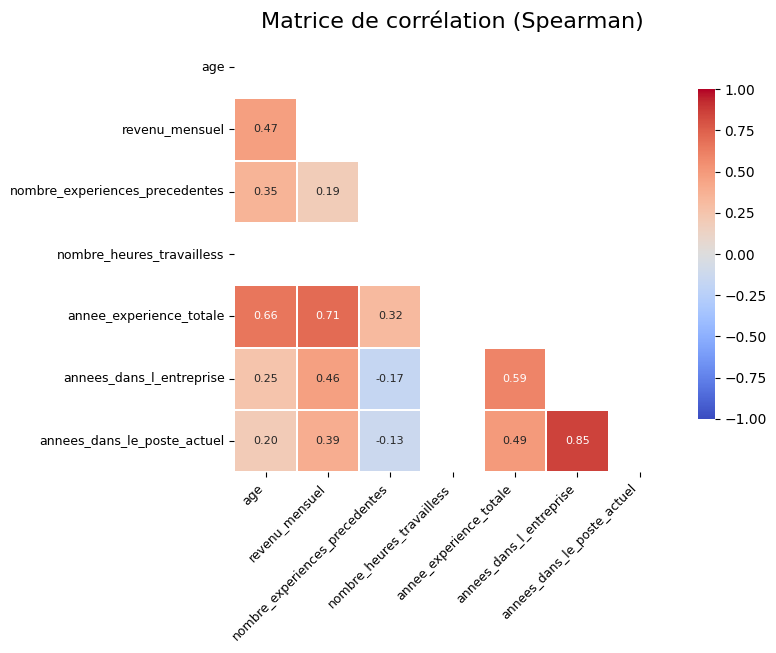

In [68]:
corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [69]:
corr = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.854000
1,revenu_mensuel,annee_experience_totale,0.710024


In [71]:
strong_corr_features = list(set(list(strong_corr['level_0'].values) + list(strong_corr['level_1'].values)))
X = info[strong_corr_features].replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
vif_data[vif_data['VIF'] > 5]

,feature,VIF
0,annees_dans_le_poste_actuel,5.189112
1,annee_experience_totale,8.915268
2,revenu_mensuel,6.917388
3,annees_dans_l_entreprise,7.084440


# A.2 Table df_eval

## Premier nettoyage des données 🧹

In [17]:
df_eval.head(5)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [18]:
df_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   eval_number                                1470 non-null   object
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   object
dtypes: int64(7), object(3)
memory usage:

### Valeurs nulles 👌(❎ pas de valeur nulle)

In [19]:
df_eval.isna().mean().sort_values(ascending=False)

satisfaction_employee_environnement          0.0
note_evaluation_precedente                   0.0
niveau_hierarchique_poste                    0.0
satisfaction_employee_nature_travail         0.0
satisfaction_employee_equipe                 0.0
satisfaction_employee_equilibre_pro_perso    0.0
eval_number                                  0.0
note_evaluation_actuelle                     0.0
heure_supplementaires                        0.0
augementation_salaire_precedente             0.0
dtype: float64

### Suppression des doublons 👥 (❎ Pas de doublons)

In [20]:
df_eval.duplicated().sum()

0

### Convertion des données ☪️

In [21]:
df_eval.eval_number.nunique(), df_eval.shape # Clé unique de la table

(1470, (1470, 10))

In [22]:
df_eval.heure_supplementaires.value_counts(normalize=True).round(2)

heure_supplementaires
Non    0.72
Oui    0.28
Name: proportion, dtype: float64

In [23]:
df_eval["heure_supplementaires"] = (
    df_eval["heure_supplementaires"]
    .map({"Oui": 1, "Non": 0})
)

In [24]:
df_eval.columns

Index(['satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'eval_number',
       'note_evaluation_actuelle', 'heure_supplementaires',
       'augementation_salaire_precedente'],
      dtype='object')

In [25]:
df_eval["augementation_salaire_precedente"] = (
    df_eval["augementation_salaire_precedente"]
    .str.replace("%", "", regex=False)   # enlève %
    .str.replace(",", ".", regex=False)  # remplace virgule
    .str.strip()                         # enlève espaces
    .astype(float) / 100                 # convertit en proportion
)

## Analyses univariés

### A. Variables ordinales (satisfaction + niveau)

In [26]:
for col in df_eval.filter(like="satisfaction"):
    print(df_eval[col].value_counts(normalize=True))

satisfaction_employee_environnement
3    0.308163
4    0.303401
2    0.195238
1    0.193197
Name: proportion, dtype: float64
satisfaction_employee_nature_travail
4    0.312245
3    0.300680
1    0.196599
2    0.190476
Name: proportion, dtype: float64
satisfaction_employee_equipe
3    0.312245
4    0.293878
2    0.206122
1    0.187755
Name: proportion, dtype: float64
satisfaction_employee_equilibre_pro_perso
3    0.607483
2    0.234014
4    0.104082
1    0.054422
Name: proportion, dtype: float64


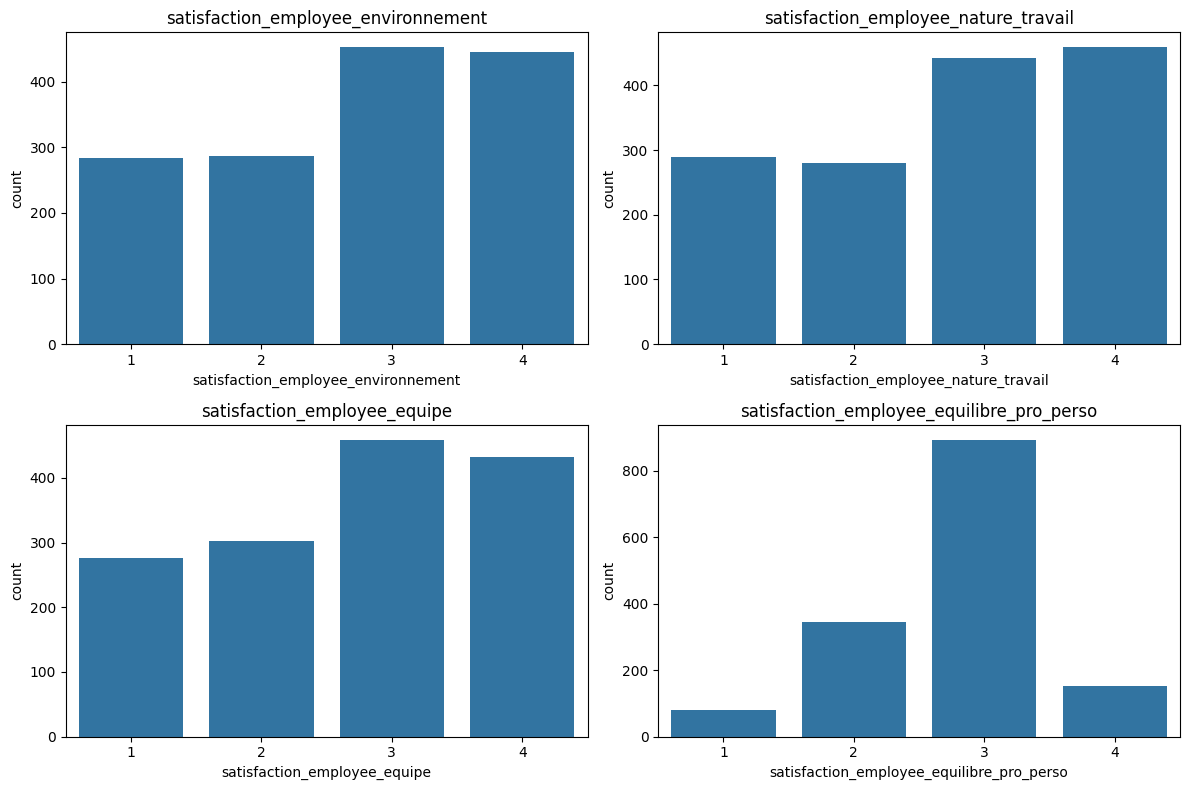

In [27]:
cols = df_eval.filter(like="satisfaction").columns

n_cols = 2  # 👉 2 graphes par ligne
n_plots = len(cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=df_eval[col], ax=axes[i])
    axes[i].set_title(col)

# supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

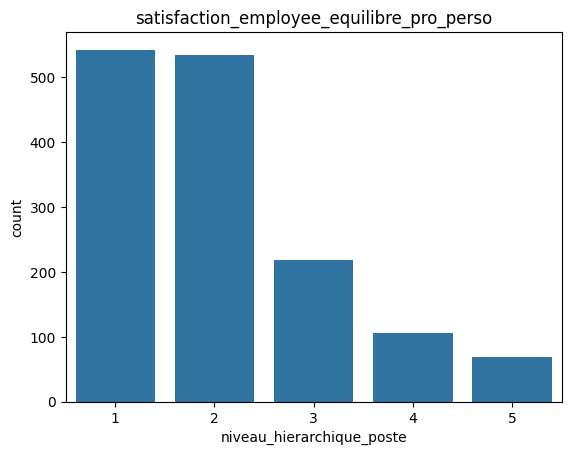

In [28]:
sns.countplot(x=df_eval["niveau_hierarchique_poste"])
plt.title(col)
plt.show()

In [29]:
satisfaction_cols = df_eval.filter(like="satisfaction").columns

df_eval["satisfaction_global"] = df_eval[satisfaction_cols].mean(axis=1)

<Axes: xlabel='satisfaction_global', ylabel='Count'>

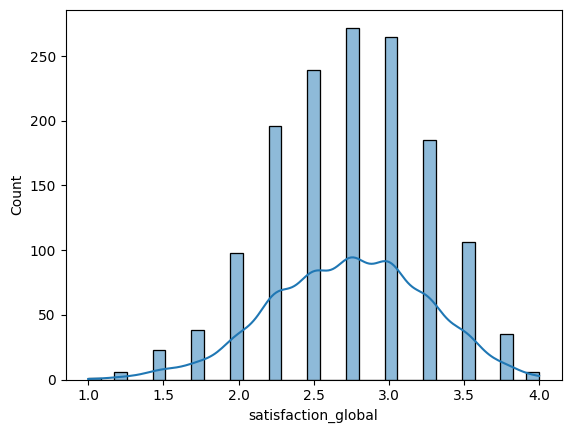

In [30]:
sns.histplot(df_eval["satisfaction_global"], kde=True)

### B. Variables quantitatives

In [31]:
df_eval["augementation_salaire_precedente"].describe()

count    1470.000000
mean        0.152095
std         0.036599
min         0.110000
25%         0.120000
50%         0.140000
75%         0.180000
max         0.250000
Name: augementation_salaire_precedente, dtype: float64

<Axes: xlabel='augementation_salaire_precedente', ylabel='Count'>

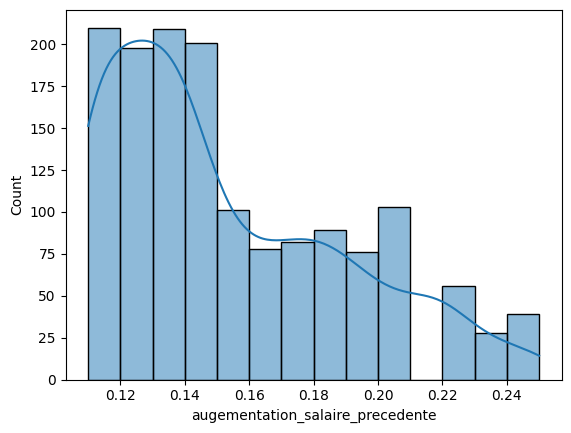

In [32]:
sns.histplot(df_eval["augementation_salaire_precedente"], kde=True)

In [33]:
df_eval.note_evaluation_actuelle.value_counts()

note_evaluation_actuelle
3    1244
4     226
Name: count, dtype: int64

#### Outliers 😶

In [72]:
data = df_eval.drop(["eval_number","heure_supplementaires"],axis=1).select_dtypes(include="number")

In [35]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.00,2.00,3.00,4.00,4.00
note_evaluation_precedente,1470.0,2.729932,0.711561,1.00,2.00,3.00,3.00,4.00
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.00,1.00,2.00,3.00,5.00
satisfaction_employee_nature_travail,1470.0,2.728571,1.102846,1.00,2.00,3.00,4.00,4.00
satisfaction_employee_equipe,1470.0,2.712245,1.081209,1.00,2.00,3.00,4.00,4.00
satisfaction_employee_equilibre_pro_perso,1470.0,2.761224,0.706476,1.00,2.00,3.00,3.00,4.00
note_evaluation_actuelle,1470.0,3.153741,0.360824,3.00,3.00,3.00,3.00,4.00
augementation_salaire_precedente,1470.0,0.152095,0.036599,0.11,0.12,0.14,0.18,0.25
satisfaction_global,1470.0,2.730952,0.505815,1.00,2.50,2.75,3.00,4.00


In [36]:
outliers, ratio = of.detect_outliers_iqr(data)
ratio.sort_values(ascending=False)

note_evaluation_actuelle                     15.37415
satisfaction_global                           2.44898
satisfaction_employee_environnement           0.00000
note_evaluation_precedente                    0.00000
niveau_hierarchique_poste                     0.00000
satisfaction_employee_nature_travail          0.00000
satisfaction_employee_equipe                  0.00000
satisfaction_employee_equilibre_pro_perso     0.00000
augementation_salaire_precedente              0.00000
dtype: float64

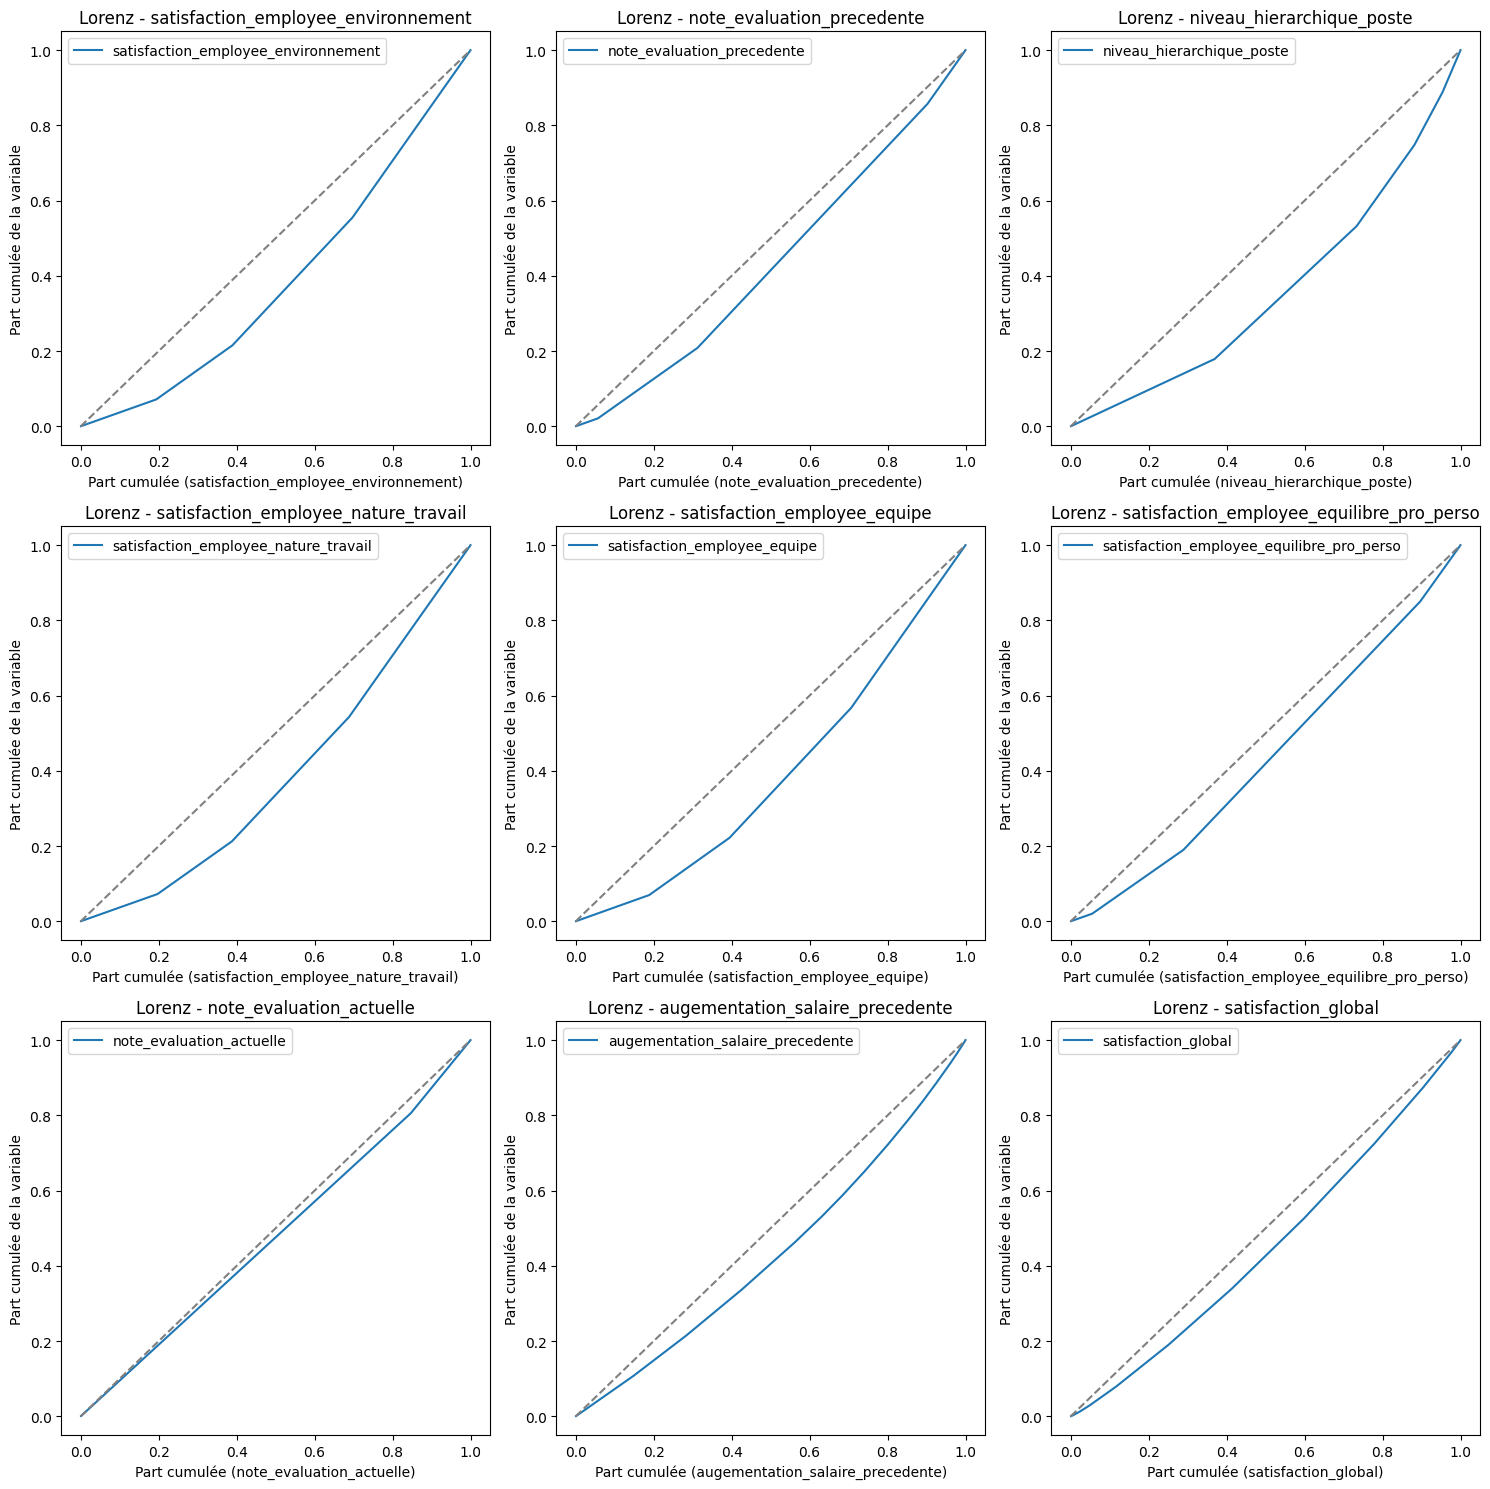

In [37]:
n_cols = 3
n_plots = len(data.columns)

n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, (col, serie) in enumerate(data.items()):
    of.plot_lorenz(
        serie,
        ax=axes[i],
        label=col,
        title=f"Lorenz - {col}"
    )

# Supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

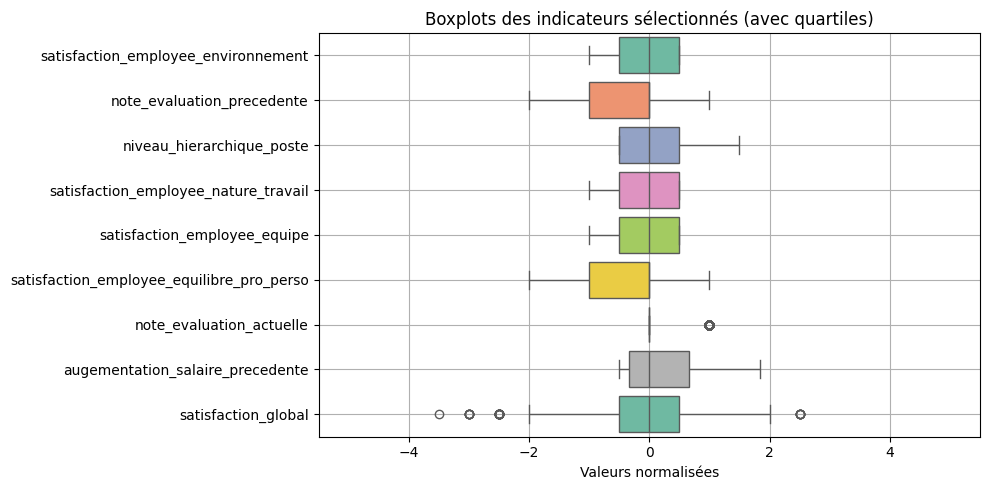

In [73]:
data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data),
    columns=data.columns
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("")
plt.xlabel("Valeurs normalisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Skwed

In [38]:
data.skew()

satisfaction_employee_environnement         -0.321654
note_evaluation_precedente                  -0.498419
niveau_hierarchique_poste                    1.025401
satisfaction_employee_nature_travail        -0.329672
satisfaction_employee_equipe                -0.302828
satisfaction_employee_equilibre_pro_perso   -0.552480
note_evaluation_actuelle                     1.921883
augementation_salaire_precedente             0.821128
satisfaction_global                         -0.199736
dtype: float64

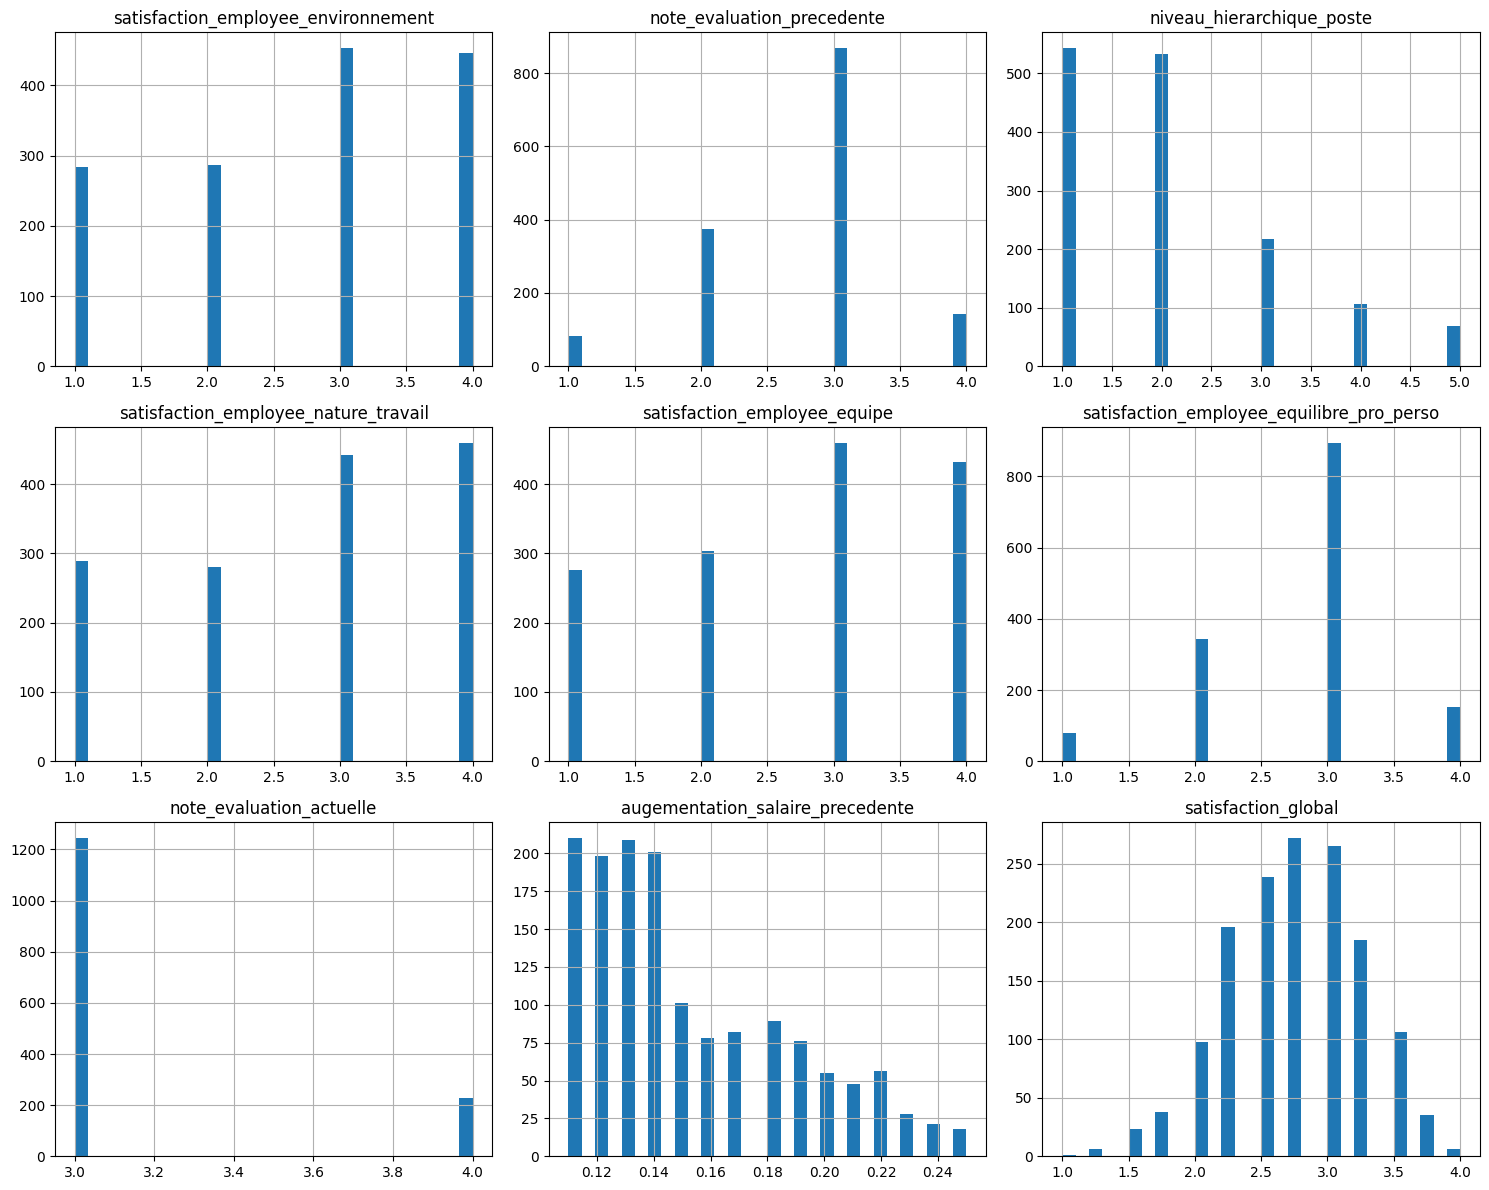

In [39]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

### C. Variable binaires (heure supplémentaires)

In [40]:
df_eval["heure_supplementaires"].value_counts(normalize=True)

heure_supplementaires
0    0.717007
1    0.282993
Name: proportion, dtype: float64

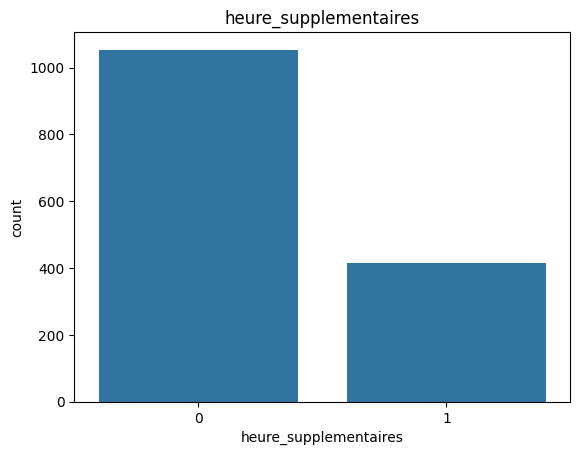

In [41]:
sns.countplot(x=df_eval["heure_supplementaires"]) 
plt.title("heure_supplementaires") 
plt.show()

## Analyses bivariées

In [77]:
df_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   satisfaction_employee_environnement        1470 non-null   int64  
 1   note_evaluation_precedente                 1470 non-null   int64  
 2   niveau_hierarchique_poste                  1470 non-null   int64  
 3   satisfaction_employee_nature_travail       1470 non-null   int64  
 4   satisfaction_employee_equipe               1470 non-null   int64  
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 6   eval_number                                1470 non-null   object 
 7   note_evaluation_actuelle                   1470 non-null   int64  
 8   heure_supplementaires                      1470 non-null   int64  
 9   augementation_salaire_precedente           1470 non-null   float64
 10  satisfaction_global     

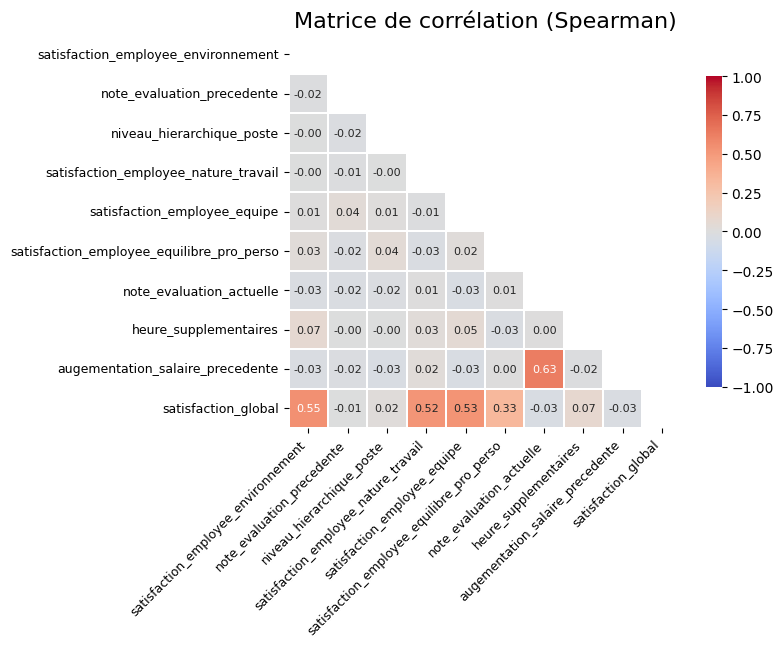

In [78]:
corr_matrix = df_eval.select_dtypes(include='number').corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# A.3 Table sondage 

In [42]:
poll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   object
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [43]:
poll.head(5)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


## Premier nettoyage des données 🧹

### Valeurs nulles 👌(❎ pas de valeurs nulles)

In [44]:
poll.isna().mean()

a_quitte_l_entreprise                  0.0
nombre_participation_pee               0.0
nb_formations_suivies                  0.0
nombre_employee_sous_responsabilite    0.0
code_sondage                           0.0
distance_domicile_travail              0.0
niveau_education                       0.0
domaine_etude                          0.0
ayant_enfants                          0.0
frequence_deplacement                  0.0
annees_depuis_la_derniere_promotion    0.0
annes_sous_responsable_actuel          0.0
dtype: float64

### Suppression des doublons 👥 (❎ Pas de doublons)

In [45]:
poll.duplicated().sum()

0

## Analyses univariées

### A.Valeurs ordinales (domaine_etude, frequence_déplacement)

In [46]:
poll.domaine_etude.value_counts()

domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64

In [47]:
poll.columns

Index(['a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'code_sondage', 'distance_domicile_travail', 'niveau_education',
       'domaine_etude', 'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

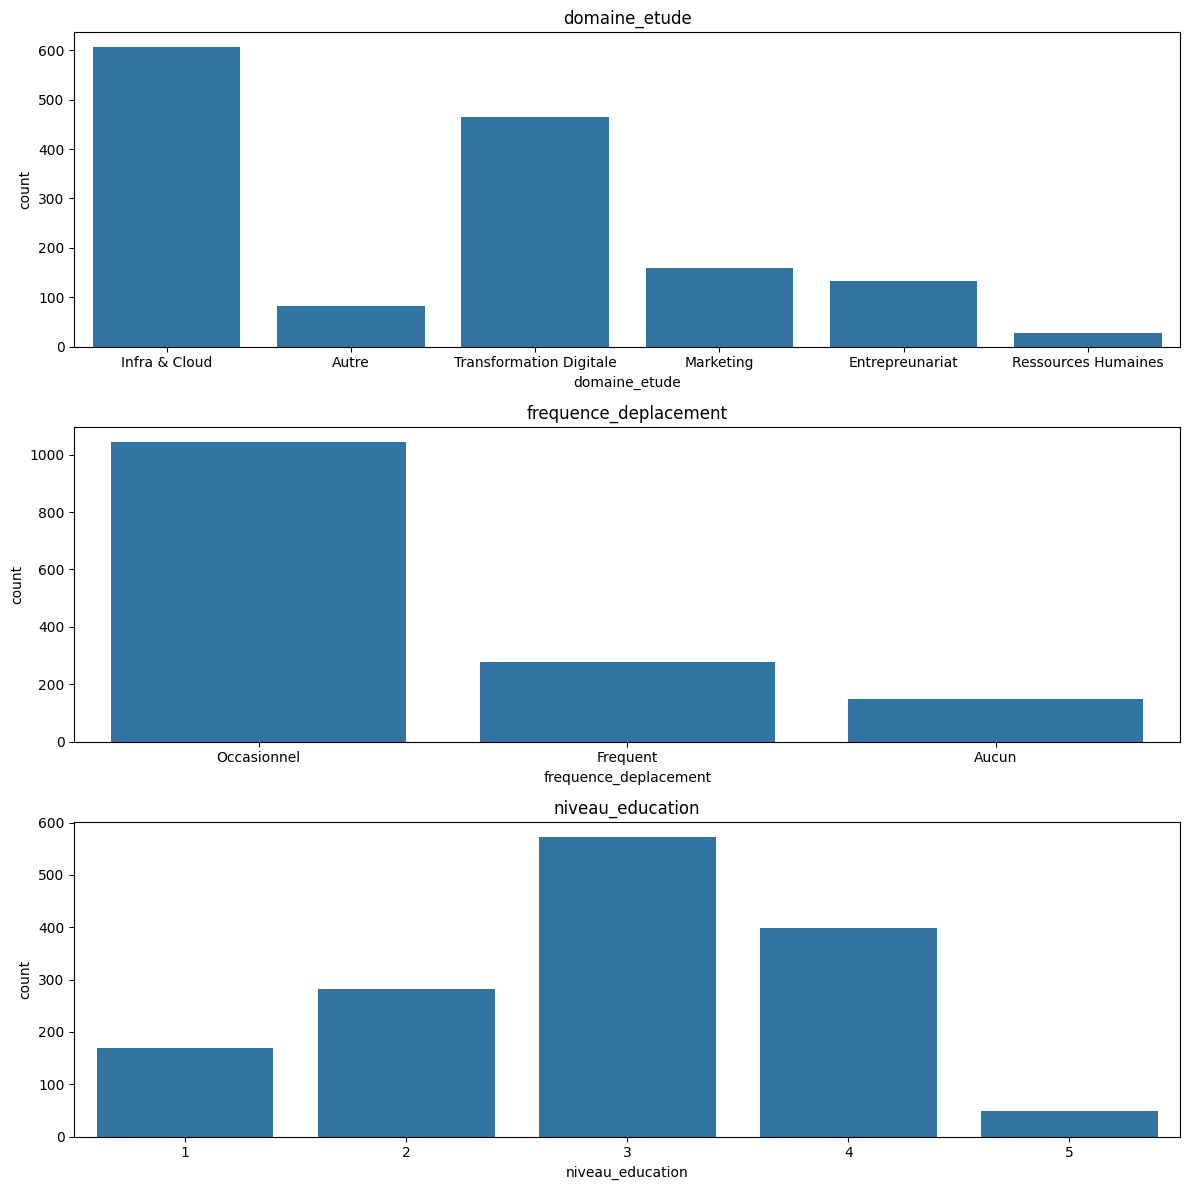

In [48]:
cols = poll[["domaine_etude","frequence_deplacement","niveau_education"]].columns

n_cols = 1  # 👉 2 graphes par ligne
n_plots = len(cols)
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=poll[col], ax=axes[i])
    axes[i].set_title(col)

# supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### B. Valeurs quantitatives

In [74]:
data = poll[['nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'distance_domicile_travail', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']].copy()

#### Swed

In [50]:
data.skew().sort_values(ascending=False)

annees_depuis_la_derniere_promotion    1.984290
nombre_participation_pee               0.968980
distance_domicile_travail              0.958118
annes_sous_responsable_actuel          0.833451
nb_formations_suivies                  0.553124
nombre_employee_sous_responsabilite    0.000000
dtype: float64

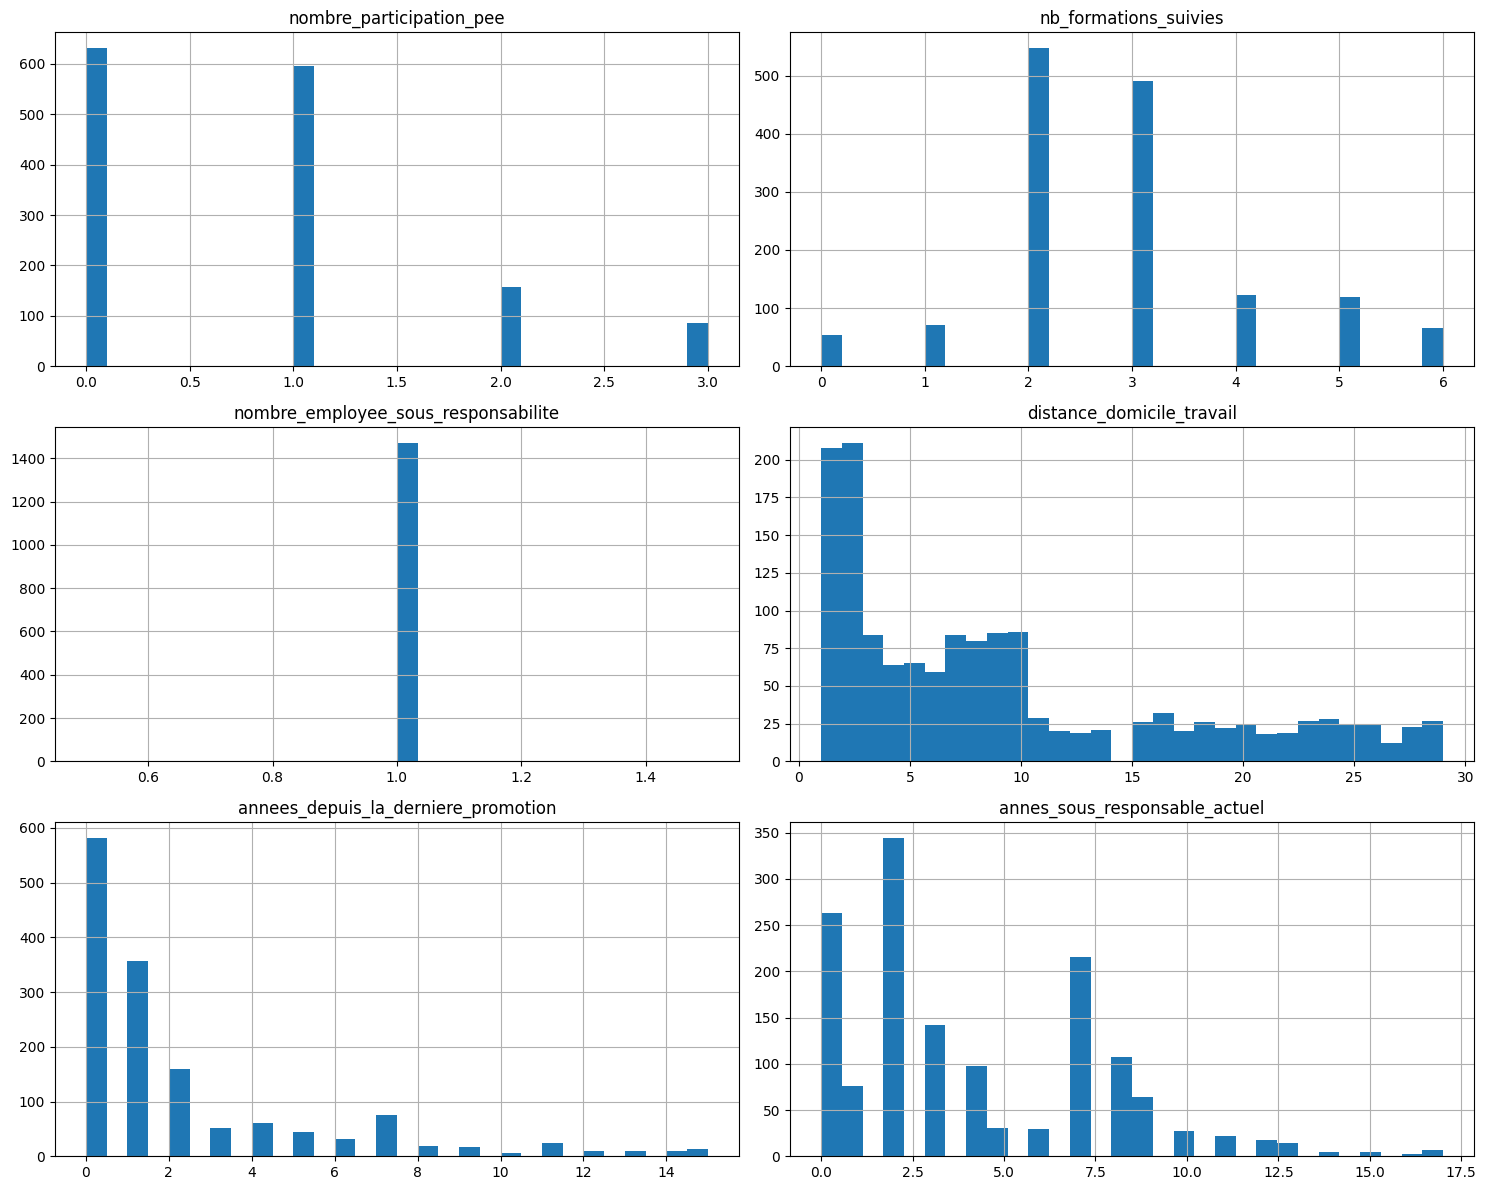

In [51]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

In [52]:
poll.nombre_employee_sous_responsabilite.describe()

count    1470.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: nombre_employee_sous_responsabilite, dtype: float64

#### Outliers

In [53]:
outliers, ratio = of.detect_outliers_iqr(data)
ratio.sort_values(ascending=False)

nb_formations_suivies                  16.190476
annees_depuis_la_derniere_promotion     7.278912
nombre_participation_pee                5.782313
annes_sous_responsable_actuel           0.952381
nombre_employee_sous_responsabilite     0.000000
distance_domicile_travail               0.000000
dtype: float64

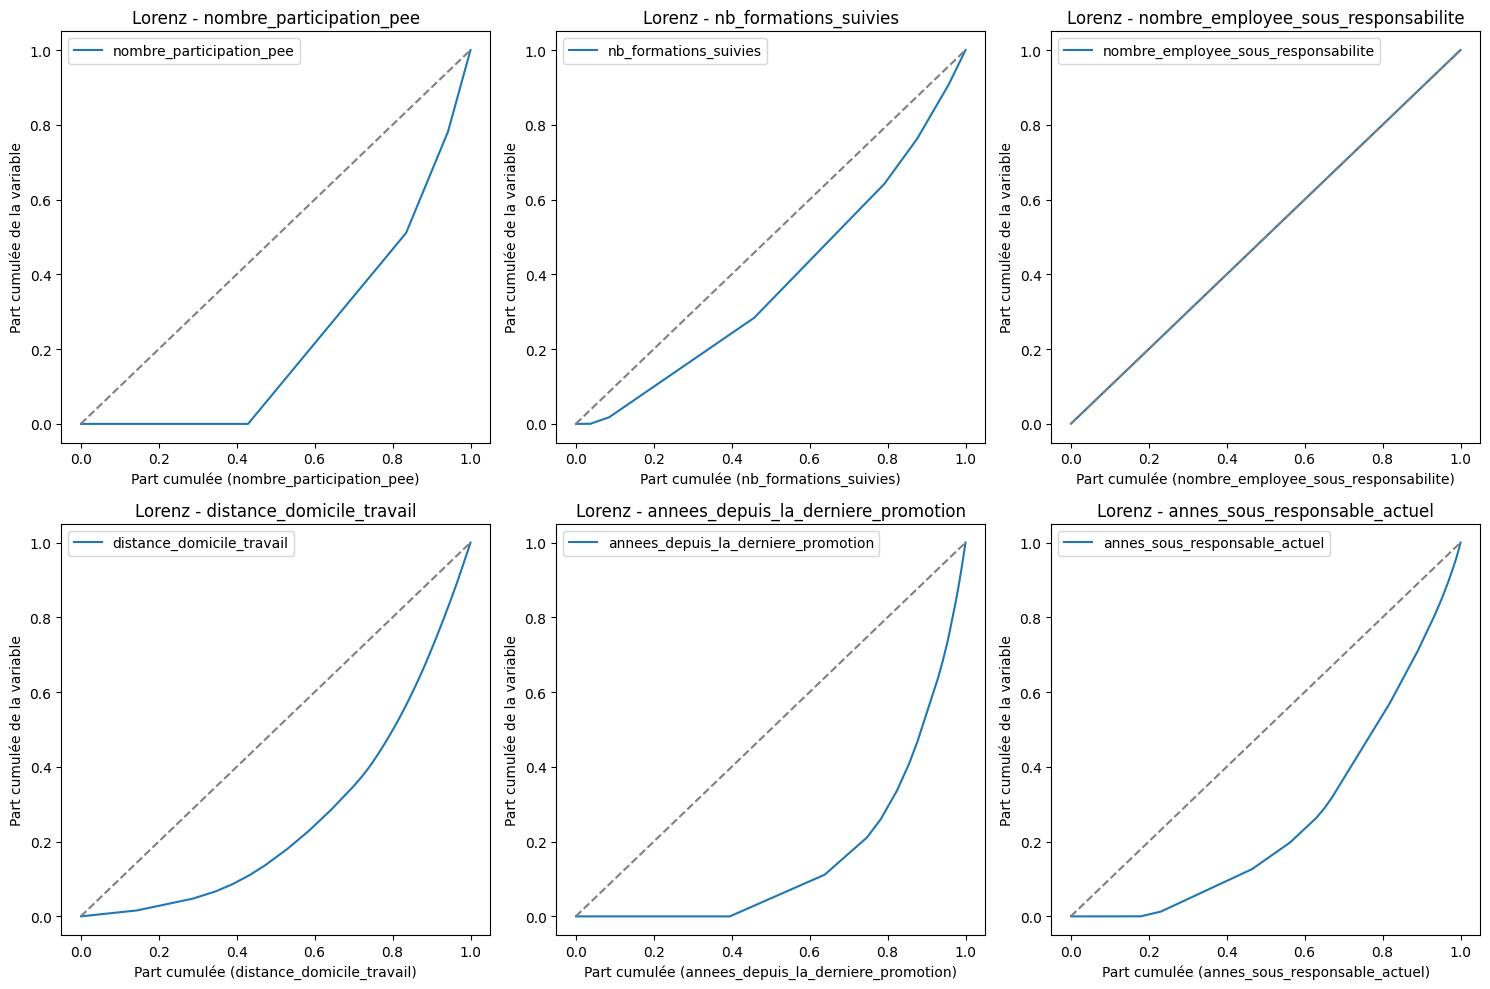

In [54]:
n_cols = 3
n_plots = len(data.columns)

n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, (col, serie) in enumerate(data.items()):
    of.plot_lorenz(
        serie,
        ax=axes[i],
        label=col,
        title=f"Lorenz - {col}"
    )

# Supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

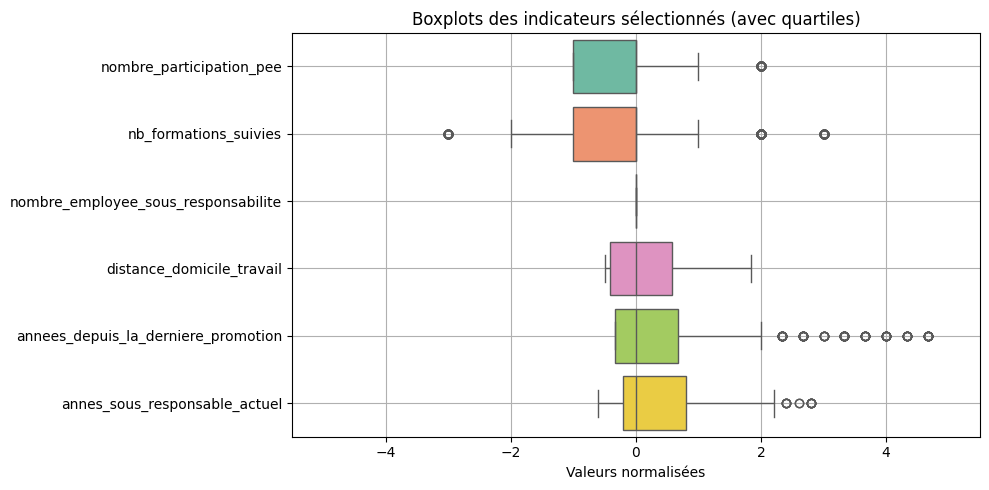

In [75]:
data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data),
    columns=data.columns
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("")
plt.xlabel("Valeurs normalisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()

### C. Valeurs binaires

In [55]:
poll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   object
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [56]:
poll.a_quitte_l_entreprise.value_counts(normalize=True)

a_quitte_l_entreprise
Non    0.838776
Oui    0.161224
Name: proportion, dtype: float64

In [57]:
poll["a_quitte_l_entreprise"] = (
    poll["a_quitte_l_entreprise"]
    .map({"Oui": 1, "Non": 0})
)

In [58]:
poll.ayant_enfants.value_counts() # valeur aberrante, à supprimer

ayant_enfants
Y    1470
Name: count, dtype: int64